In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from joblib import dump, load

from xai_aux import CFCalculations

In [54]:
pd.set_option("display.max_columns", 99)

In [55]:
def get_distance(A,B, continuous_columns, categorical_columns, l_norm=2):
    
    combined = np.vstack((A, B))
    
    stds = np.std(combined[:, categorical_columns], axis=0)
    epsilon = 1e-8
    adjusted_stds = np.where(stds == 0, epsilon, stds) 

    weights_categorical = 1.48 / adjusted_stds
    mads = np.median(np.abs(combined[:, continuous_columns] - 
                            np.median(combined[:, continuous_columns], axis=0)), axis=0)
    adjusted_mads = np.where(mads == 0, epsilon, mads) 
    weights_continuous = 1 / adjusted_mads

    # Combine weights
    weights = np.zeros(combined.shape[1])
    weights[categorical_columns] = weights_categorical
    weights[continuous_columns] = weights_continuous

    # Compute weighted L2 distances for same-index pairs
    differences = A - B  # Element-wise differences
    weighted_differences = differences * weights  # Apply weights element-wise
    l_distances = np.linalg.norm(weighted_differences, axis=1, ord=l_norm)
    return l_distances

In [56]:
colours = {('lr', 'skl'): 'deepskyblue', 
           ('lr', 'blr_marg'): 'blue', 
           ('lr', 'blr_mean'): 'lightblue',
           ('lr', 'nice'): 'magenta',
           ('lr', 'dice'): 'hotpink', 
           ('lr', 'RL'): 'lavender',
           ('rf', 'nice'): 'darkorange',
           ('rf', 'dice'): 'orange',
           ('rf', 'RL'): 'palegoldenrod',
           ('tf', 'nice'): 'darkgreen', 
           ('tf', 'dice'): 'lightgreen'
           }

In [70]:
mock_data = 3
mock_data_flag = True
german_credit_flag = False
adult_income_flag = False
gsc_flag = False
l_order = 2
cm = ['TP','FP','FN','TN']

In [71]:
if mock_data_flag:
    mock_data_ext = str(mock_data)#+"_noniid_test" #"_ommited_var_test"
    cf_results_dict = load("data/cf_results_dict_mock_data"+mock_data_ext+".pkl")
    cf_calc = load("data/cf_calc_mock_data"+mock_data_ext+".pkl")
    model_results_dict = load("data/model_results_dict"+mock_data_ext+".pkl")
    cfs_good_indices = load("data/cfs_good_indices"+mock_data_ext+".pkl")

if german_credit_flag:
    cf_results_dict = load("data/cf_results_dict_german_credit.pkl")
    cf_calc = load("data/cf_calc_mock_data_german_credit.pkl")
    model_results_dict = load("data/model_results_german_credit.pkl")
    cfs_good_indices = load("data/cfs_good_indices_german_credit.pkl")

if adult_income_flag:
    cf_results_dict = load("data/cf_results_dict_adult_income.pkl")
    cf_calc = load("data/cf_calc_adult_income.pkl")
    model_results_dict = load("data/model_results_adult_income.pkl")
    cfs_good_indices = load("data/cfs_good_indices_adult_income.pkl")

if gsc_flag:
    cf_results_dict = load("data/cf_results_dict_gsc.pkl")
    cf_calc = load("data/cf_calc_gsc.pkl")
    model_results_dict = load("data/model_results_gsc.pkl")
    cfs_good_indices = load("data/cfs_good_indices_gsc.pkl")

In [72]:
noises_list = list(cf_results_dict.keys())[1:]
cf_methods = list(cf_results_dict[noises_list[0]].keys())
n_features = np.array(cf_results_dict['noise_0'][('lr','nice')]).shape[1]
numerical_columns = [int(i) for i in cf_calc.num_cols_tf]
categorical_columns = [int(i) for i in cf_calc.cat_cols_tf]

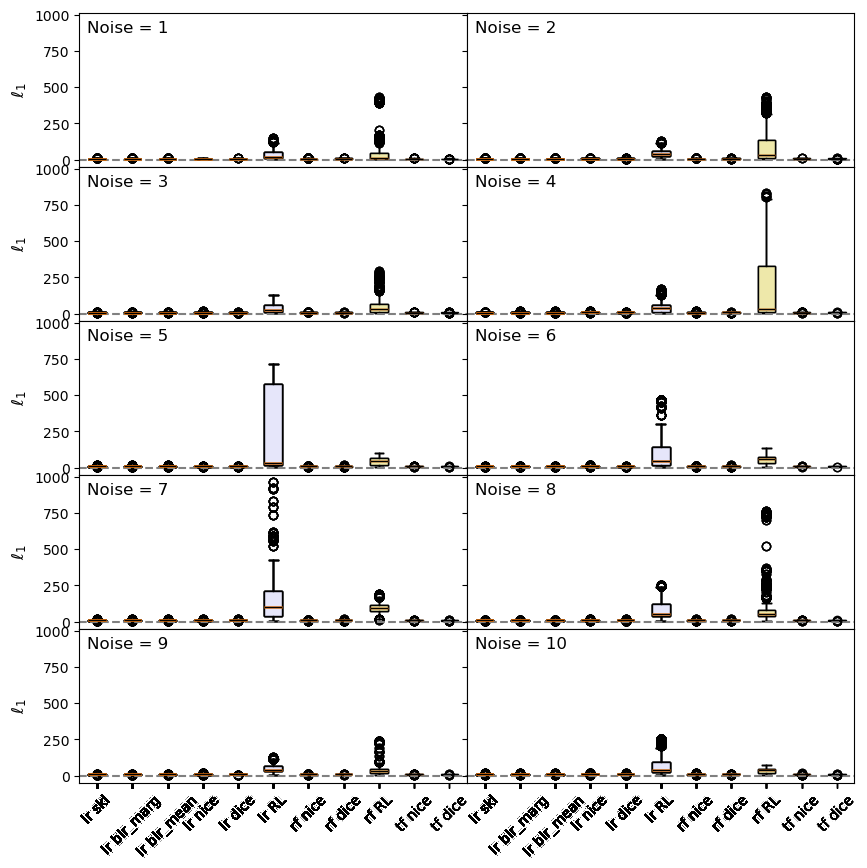

In [73]:
fig, axes = plt.subplots(5, 2, figsize=(10, 10), sharex=True, sharey=True)
axes = axes.flatten()
for i, ax in enumerate(axes):
    d2 = []
    labels = []
    colour_list = []
    for k in cf_methods:
        colour_list.append(colours[k])
        A = cf_results_dict[noises_list[i]][k]
        B = cf_results_dict['noise_0'][k]

        if k[1]=='nice' or k[1]=='dice' or k[1]=='RL':
            if k[0]!='tf':
                A = cf_calc.models[0]['PP'].transform(pd.DataFrame(A, columns=[str(j) for j in range(n_features)])).astype(float)
                B = cf_calc.models[0]['PP'].transform(pd.DataFrame(B, columns=[str(j) for j in range(n_features)])).astype(float)
        good_indices = cfs_good_indices[noises_list[i]][k]
        d2.append(get_distance(A[good_indices], B[good_indices], numerical_columns, categorical_columns, l_norm=l_order))
        #d2.append(get_distance(A, B, numerical_columns, categorical_columns, l_norm=l_order))
        labels.append(k[0]+' ' + k[1])
        bplot = ax.boxplot(d2, tick_labels=labels, widths=0.5, patch_artist=True)
    for patch, color in zip(bplot['boxes'], colour_list):
        patch.set_facecolor(color)
    for median in bplot['medians']:
        median.set_color('black')

    fig.subplots_adjust(wspace=0, hspace=0)  # Set space between subplots to zero
    ax.tick_params(axis='x', labelrotation=45)
    ax.text(0.02, 0.95,'Noise = ' + noises_list[i][6:9],fontsize=12, #fontweight='bold',
        verticalalignment='top', horizontalalignment='left',
        transform=ax.transAxes)
    ax.axhline(y=0,linestyle='--',color='grey')
    if np.mod(i,2)==0:
        ax.set_ylabel(r'$\ell_1$', fontsize=12, fontweight='bold')

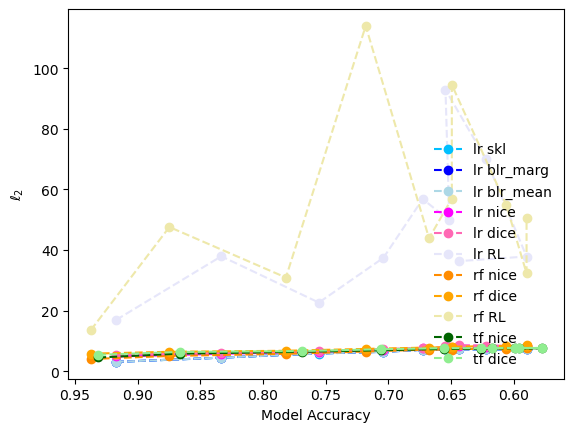

In [74]:
for i, kk in enumerate(cf_methods):
    x_acc = []
    d2 = []
    for k in cf_results_dict:
        if k=='noise_0': continue
        x_acc.append(model_results_dict[k][(kk[0],'accuracy')])
        A = cf_results_dict[k][kk]
        B = cf_results_dict['noise_0'][kk]
        if kk[1]=='nice' or kk[1]=='dice' or kk[1]=='RL':
            if kk[0]!='tf':
                A = cf_calc.models[0]['PP'].transform(pd.DataFrame(A, columns=[str(j) for j in range(n_features)])).astype(float)
                B = cf_calc.models[0]['PP'].transform(pd.DataFrame(B, columns=[str(j) for j in range(n_features)])).astype(float)
        #good_indices = cfs_good_indices[k][kk] # we ignore that because it won't work for plotting. This is a >5% level effect.
        d2.append(get_distance(A, B, numerical_columns, categorical_columns, l_norm=l_order))
        
    d2 = np.array(d2)
    plt.plot(x_acc, np.median(d2, axis=1), color=colours[kk],label=kk[0]+' '+kk[1],alpha=1, linestyle='--', marker='o')
    #plt.fill_between(x_acc, np.percentile(d2,40,axis=1), np.percentile(d2,60,axis=1), color=colours[kk],alpha=0.2)
plt.legend(frameon=False,loc='lower right')
plt.ylabel(r'$\ell_2$')
plt.xlabel('Model Accuracy')
plt.gca().invert_xaxis()

In [75]:
def model_dict_to_df(model_dict):
    df = pd.DataFrame.from_dict(model_dict, orient='index', columns=['value'])
    df.index = pd.MultiIndex.from_tuples(df.index, names=['model', 'metric'])
    df = df.unstack(level=1)
    df.columns = df.columns.droplevel(1)
    df = df.reset_index()
    df.columns = ['model','accuracy', 'precision']
    return df

In [76]:
methods2 = ['R19', 'BR19 (Mean)', 'BR19 (Marg)', 'DiCE', 'NICE', 'RL']
d2 = {'R19':[('lr', 'skl')], 
      'BR19 (Marg)':[('lr', 'blr_marg')], 
      'BR19 (Mean)':[('lr', 'blr_mean')], 
      'DiCE': [('lr', 'dice'), ('rf', 'dice'),('tf', 'dice')],
      'NICE': [('lr', 'nice'), ('rf', 'nice'),('tf', 'dice')],
      'RL': [('lr', 'RL'),('rf', 'RL')]}

In [77]:
dfs = []
dataset_in = 'mock 1'
for i in model_results_dict:
    df_t = model_dict_to_df(model_results_dict[i])
    df_t.insert(0,'Noise Level',i)
    df_t.insert(0,'Dataset',dataset_in)
    dfs.append(df_t)
df = pd.concat(dfs).reset_index(drop=True)
for j in [i+' Compl' for i in methods2]:
    df[j] = np.nan
for j in [i+' L1' for i in methods2]:
    df[j] = np.nan
for j in [i+' L2' for i in methods2]:
    df[j] = np.nan

In [84]:
cf_results_dict['noise_0'][('tf','dice')]

array([[ 0.        ,  1.        ,  0.        , ..., -0.33956084,
        -1.38394749, -1.95617247],
       [ 0.        ,  0.        ,  0.        , ...,  2.4109087 ,
        -0.77677649, -0.61572021],
       [ 0.        ,  0.        ,  0.        , ..., -1.7966851 ,
        -2.7297442 , -0.64741117],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.43313313,
        -0.31716207, -0.69239092],
       [ 1.        ,  0.        ,  0.        , ...,  2.20732999,
         0.94828969, -0.28292763],
       [ 1.        ,  0.        ,  0.        , ..., -2.86693978,
         0.69855851, -0.25538516]])

In [79]:
A[good_indices]

array([[ 0.        ,  0.        ,  1.        , ...,  2.74773717,
        -2.44640303,  0.6008755 ],
       [ 0.        ,  0.        ,  0.        , ..., -0.68352175,
         3.19615245, -0.51235908],
       [ 1.        ,  0.        ,  0.        , ..., -1.3546803 ,
        -1.70567143, -1.1944685 ],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.12833275,
         1.83467317,  0.9294197 ],
       [ 1.        ,  0.        ,  0.        , ...,  0.22798462,
         0.5949735 ,  0.46959651],
       [ 0.        ,  0.        ,  0.        , ...,  0.8674438 ,
         1.57432234, -0.0720588 ]])

In [81]:
m

('lr', 'dice')

In [87]:
for noise in list(cf_results_dict.keys()):
    for k in methods2:
        for m in d2[k]:
            try:
                compl = sum(cfs_good_indices[noise][m])/len(cfs_good_indices[noise][m])
                sel = (df['Noise Level']==noise)&(df['model']==m[0])
                df.loc[sel, k+' Compl'] = compl
                A = cf_results_dict[noise][m]
                B = cf_results_dict['noise_0'][m]
                if m[1]=='nice' or m[1]=='dice' or m[1]=='RL':
                    if m[0]!='tf':
                        A = cf_calc.models[0]['PP'].transform(pd.DataFrame(A, columns=[str(j) for j in range(n_features)])).astype(float)
                        B = cf_calc.models[0]['PP'].transform(pd.DataFrame(B, columns=[str(j) for j in range(n_features)])).astype(float)
                good_indices = cfs_good_indices[noise][m]
                df.loc[sel,k+' L1'] = get_distance(A[good_indices], B[good_indices], numerical_columns, categorical_columns, l_norm=1).mean()
                df.loc[sel,k+' L2'] = get_distance(A[good_indices], B[good_indices], numerical_columns, categorical_columns, l_norm=2).mean()
            except KeyError:
                pass
df

,Dataset,Noise Level,model,accuracy,precision,R19 Compl,BR19 (Mean) Compl,BR19 (Marg) Compl,DiCE Compl,NICE Compl,RL Compl,R19 L1,BR19 (Mean) L1,BR19 (Marg) L1,DiCE L1,NICE L1,RL L1,R19 L2,BR19 (Mean) L2,BR19 (Marg) L2,DiCE L2,NICE L2,RL L2
0,mock 1,noise_0,blr,0.986869,0.986876,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,mock 1,noise_0,lr,0.986869,0.986876,1.0,1.0,0.944444,1.000000,1.0,0.733333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,mock 1,noise_0,rf,0.991919,0.991934,NaN,NaN,NaN,0.917172,1.0,0.725253,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000
3,mock 1,noise_0,tf,0.989899,0.989899,NaN,NaN,NaN,1.000000,1.0,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN
4,mock 1,noise_1,blr,0.915152,0.915409,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,mock 1,noise_1,lr,0.917172,0.917327,1.0,1.0,1.000000,1.000000,1.0,0.848485,5.766333,5.866308,5.866307,10.204529,9.383263,43.616778,3.258602,3.318415,3.318415,5.289858,4.875048,31.335813
6,mock 1,noise_1,rf,0.937374,0.937429,NaN,NaN,NaN,0.944444,1.0,0.780808,NaN,NaN,NaN,11.191313,8.959257,63.430806,NaN,NaN,NaN,5.761745,4.333367,49.440795
7,mock 1,noise_1,tf,0.931313,0.931218,NaN,NaN,NaN,1.000000,1.0,NaN,NaN,NaN,NaN,10.020104,10.020104,NaN,NaN,NaN,NaN,5.359581,5.359581,NaN
8,mock 1,noise_2,blr,0.832323,0.831560,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,mock 1,noise_2,lr,0.833333,0.832573,1.0,1.0,1.000000,1.000000,1.0,0.931313,8.901499,8.956314,8.956314,12.821348,12.805043,60.689502,4.446308,4.474545,4.474545,6.036103,5.877210,42.923265


In [ ]:
for noise in list(cf_results_dict.keys())[0:1]:
    print(noise)
    d2 = []
    compl = []
    ncf = []
    for k in cf_methods:
        print(k)
        A = cf_results_dict[noise][k]
        B = cf_results_dict['noise_0'][k]
        if k[1]=='nice' or k[1]=='dice' or k[1]=='RL':
            if k[0]!='tf':
                A = cf_calc.models[0]['PP'].transform(pd.DataFrame(A, columns=[str(j) for j in range(n_features)])).astype(float)
                B = cf_calc.models[0]['PP'].transform(pd.DataFrame(B, columns=[str(j) for j in range(n_features)])).astype(float)
        good_indices = cfs_good_indices[noise][k]
        ncf.append(len(good_indices))
        compl.append(good_indices.sum()/len(good_indices))
        d2.append(get_distance(A[good_indices], B[good_indices], numerical_columns, categorical_columns, l_norm=l_order))

noise_0
('lr', 'skl')
('lr', 'blr_marg')
('lr', 'blr_mean')
('lr', 'nice')
('lr', 'dice')
('lr', 'RL')
('rf', 'nice')
('rf', 'dice')
('rf', 'RL')
('tf', 'nice')
('tf', 'dice')
